In [1]:
from IPython.core.display import HTML
HTML("""
<style>
    /* Targets JupyterLab, Classic Notebooks, and VS Code workspaces */
    #notebook-container, .jp-Notebook, .jp-Cell, .jp-Notebook-panel {
        background-color: #2D68C4 !important;
    }
    
    /* Forces Markdown text and headers to turn white for contrast */
    .rendered_html, .jp-RenderedHTMLCommon, 
    .rendered_html p, .rendered_html h1, .rendered_html h2, .rendered_html h3 {
        color: #ffffff !important;
    }
    
    /* Optional: Tweaks code cell borders so they don't look completely invisible */
    .jp-InputArea-editor, .CodeMirror {
        border: 1px solid rgba(255, 255, 255, 0.2) !important;
    }
</style>
""")


<h1 style = "color: #FFD100;"><strong><em><center>Pokémon Study - Interpreting the Characteristics of Pokémon Characters</strong></em></center></h1>

<h2 style = "color: #FFD100;"><strong><center>Statistical Investigation Question:</strong></center></h2>

<h3 style = "color: #FFD100;"><center>How do the base egg steps of 1st-generation Pokémon characters compare to the base egg steps of 2nd-generation Pokémon characters?</center>

<h2 style = "color: #FFD100;"><strong><center>Type of Statistical Study:</strong></center></h2>

<h3 style = "color: #FFD100;"><center>I plan to conduct a census as my statistical investigation because I'm not looking at a sample of Pokémon characters. Rather, I'll need to use every single Pokémon character from both the first and second generations. Additionally, I have the opportunity to access the entire population of Pokémon.</center>

In [2]:
import pandas as pd
import seaborn as sns
# Imports Python's main plotting tool, nicknaming it to plt.
import matplotlib.pyplot as plt

In [3]:
pokemon = pd.read_csv("pokemon.csv")

In [4]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   national_number     1025 non-null   int64  
 1   gen                 1025 non-null   str    
 2   english_name        1025 non-null   str    
 3   japanese_name       1025 non-null   str    
 4   primary_type        1025 non-null   str    
 5   secondary_type      526 non-null    str    
 6   classification      1025 non-null   str    
 7   percent_male        870 non-null    float64
 8   percent_female      870 non-null    float64
 9   height_m            1025 non-null   float64
 10  weight_kg           1025 non-null   float64
 11  capture_rate        1025 non-null   str    
 12  base_egg_steps      1025 non-null   int64  
 13  hp                  1025 non-null   int64  
 14  attack              1025 non-null   int64  
 15  defense             1025 non-null   int64  
 16  sp_attack        

<Axes: xlabel='base_egg_steps', ylabel='Count'>

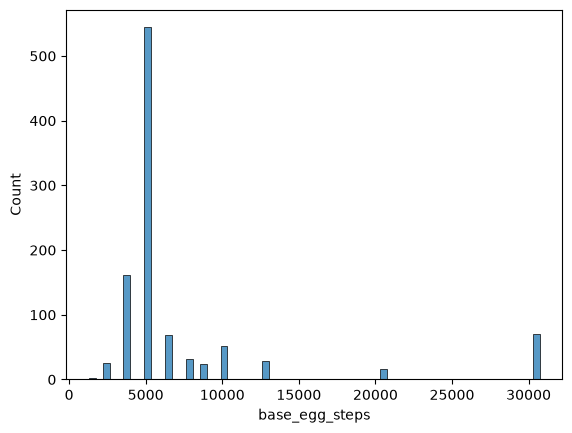

In [5]:
sns.histplot(data = pokemon, x = "base_egg_steps")

<h3 style = "color: #FFD100;"><center>According to my histogram above, the curve is strongly right-skewed. As a result, I SHOULD NOT use standard deviation and instead use interquartile range.</center>

In [6]:
gen1_mean = pokemon[pokemon["gen"] == "I"]["base_egg_steps"].mean()
print("Base egg steps mean (1st generation): ", int(gen1_mean),"steps")

Base egg steps mean (1st generation):  5933 steps


In [7]:
gen2_mean = pokemon[pokemon["gen"] == "II"]["base_egg_steps"].mean()
print("Base egg steps mean (2nd generation): ", int(gen2_mean), "steps")

Base egg steps mean (2nd generation):  6528 steps


In [8]:
gen1_median = pokemon[pokemon["gen"] == "I"]["base_egg_steps"].median()
print("Base egg steps median (1st generation): ", int(gen1_median), "steps")

Base egg steps median (1st generation):  5120 steps


In [9]:
gen2_median = pokemon[pokemon["gen"] == "II"]["base_egg_steps"].median()
print("Base egg steps median (2nd generation): ", int(gen2_median), "steps")

Base egg steps median (2nd generation):  5120 steps


In [10]:
gen1_mode = pokemon[pokemon["gen"] == "I"]["base_egg_steps"].mode()[0]
print("Base egg steps mode (1st generation): ", int(gen1_mode), "steps")

Base egg steps mode (1st generation):  5120 steps


In [11]:
gen2_mode = pokemon[pokemon["gen"] == "II"]["base_egg_steps"].mode()[0]
print("Base egg steps mode (2nd generation): ", int(gen2_mode), "steps")

Base egg steps mode (2nd generation):  5120 steps


In [12]:
q3 = pokemon[pokemon["gen"] == "I"]["base_egg_steps"].quantile(0.75)
q1 = pokemon[pokemon["gen"] == "II"]["base_egg_steps"].quantile(0.25)

In [13]:
print((q3 - q1) * 1.5)

0.0


<Axes: xlabel='gen', ylabel='base_egg_steps'>

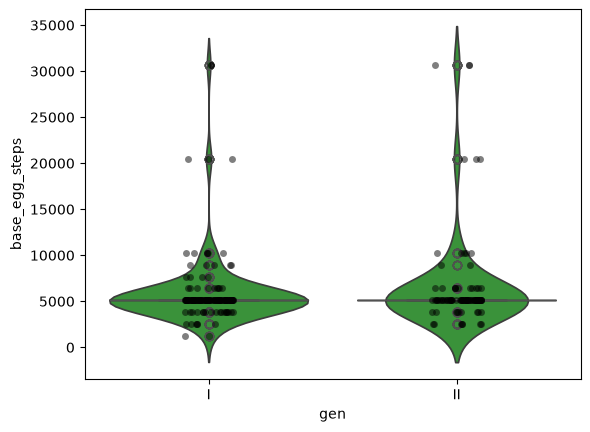

In [14]:
sns.boxplot(
    data = pokemon[pokemon["gen"].isin(["I", "II"])], 
    x = "gen", 
    y = "base_egg_steps"
)
sns.boxplot(data=pokemon[pokemon["gen"].isin(["I", "II"])], x="gen", y="base_egg_steps")
sns.stripplot(data=pokemon[pokemon["gen"].isin(["I", "II"])], x="gen", y="base_egg_steps", color="black", alpha=0.5)
sns.violinplot(data=pokemon[pokemon["gen"].isin(["I", "II"])], x="gen", y="base_egg_steps")

<h2 style = "color: #FFD100;"><strong><center>Analysis of Data:</strong></center></h2>

<h3 style = "color: #FFD100;"><center>For the graph above, we can see that the base egg steps of the majority of Pokémon characters in the first and second generations are in the ranges of 0-10000. This means that everything else above that range are considered outliers.</center>

<h2 style = "color: #FFD100;"><strong><center>Desmos Histogram & Boxplot Graph:</strong></center></h2>

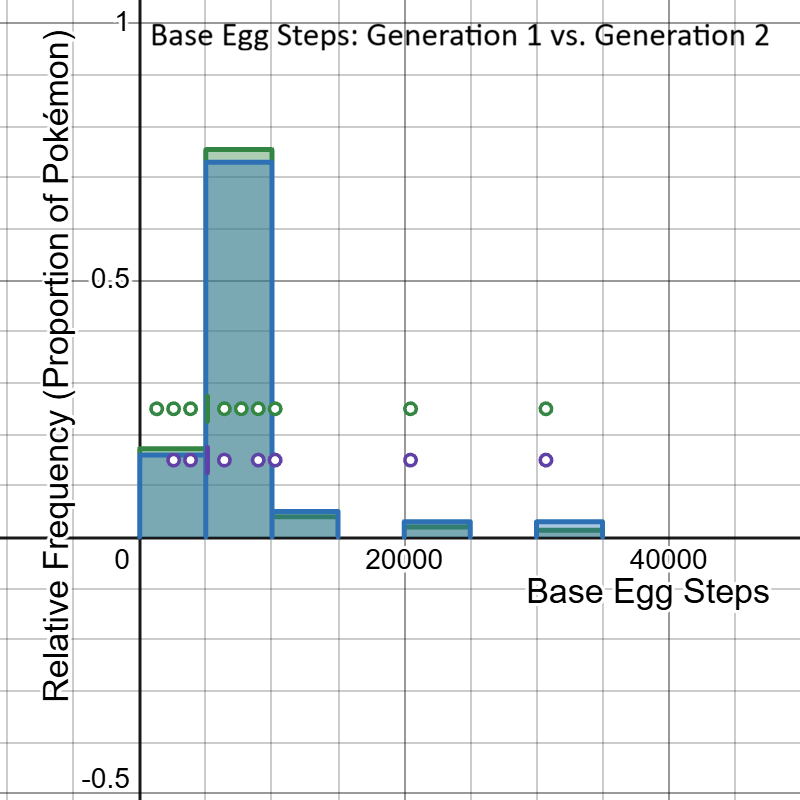

In [15]:
from IPython.display import Image, display
display(Image(filename="ACTUAL Pokemon Graph.png", width=1000))

<h2 style = "color: #FFD100;"><strong><center>Desmos Histogram and Barplot Graph Legend/Key:</strong></center></h2>

<h3 style = "color: #FFD100;"><center>Green Histogram Bars & Box Plot: Represents Generation 1 Pokémon base egg steps.</center>
<h3 style = "color: #FFD100;"><center>Blue Histogram Bars & Box Plot: Represents Generation 2 Pokémon base egg steps.</center>
<h3 style = "color: #FFD100;"><center>Teal/Dark Blue Overlap (in the tallest bar): Shows where both Gen 1 & Gen 2 overlap, showing that both generations have pretty much the exact same proportion of Pokémon requiring 5,120 base egg steps.</center>
<h3 style = "color: #FFD100;"><center>Green Dots: Individual Gen 1 outlier Pokémon.</center>
<h3 style = "color: #FFD100;"><center>Purple Dots: Individual Gen 2 outlier Pokémon.</center>

<h2 style = "color: #FFD100;"><strong><center>Conclusion:</strong></center></h2>

<h3 style = "color: #FFD100;"><center>Gen 1 Range: 30,720-1,280=29,440 steps.</center>
<h3 style = "color: #FFD100;"><center>Gen 2 Range: 30,720-2,560=28,160 steps.</center>
<h3 style = "color: #FFD100;"><center>As for the interquartile range (IQR) of both Pokémon generations is the same because over 70% of Pokémon in both generations need exactly 5,120 base egg steps.</center>
<h3 style = "color: #FFD100;"><center>Since the IQR = 0, this proves that the middle 50% of Pokémon eggs have no variation at all. They are clustered right at 5,120 steps.</center>